In [2]:
!pip install xarray

  Using cached xarray-2025.4.0-py3-none-any.whl.metadata (12 kB)
Using cached xarray-2025.4.0-py3-none-any.whl (1.3 MB)


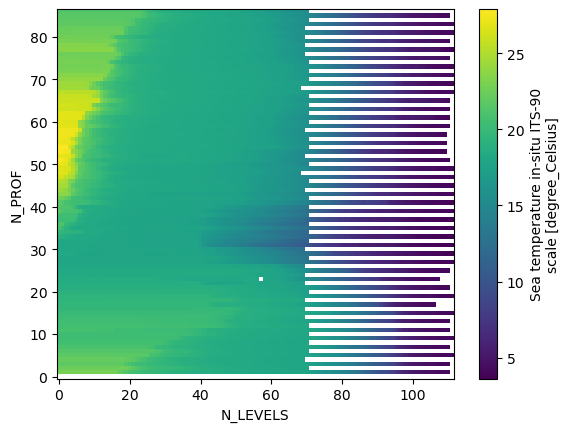

In [3]:
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm
ds = xr.open_dataset("2726_Sprof.nc")
#temperature
ds.TEMP.plot.pcolormesh()

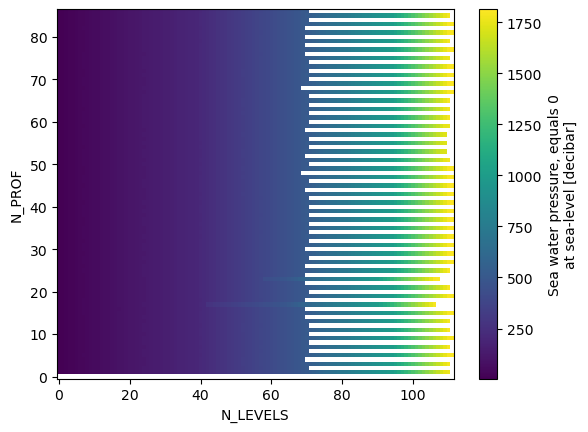

In [4]:
ds.PRES.plot.pcolormesh()

In [4]:
#use density package to plot density functions
#plug density into stratification equation
#plot on map 
#add date and time

ds = xr.open_dataset("2719_Sprof.nc")
print(ds)

<xarray.Dataset> Size: 2MB
Dimensions:                       (N_PROF: 140, N_PARAM: 4, N_LEVELS: 112,
                                   N_CALIB: 1)
Dimensions without coordinates: N_PROF, N_PARAM, N_LEVELS, N_CALIB
Data variables: (12/55)
    DATA_TYPE                     object 8B ...
    FORMAT_VERSION                object 8B ...
    HANDBOOK_VERSION              object 8B ...
    REFERENCE_DATE_TIME           object 8B ...
    DATE_CREATION                 object 8B ...
    DATE_UPDATE                   object 8B ...
    ...                            ...
    DOXY_ADJUSTED_ERROR           (N_PROF, N_LEVELS) float32 63kB ...
    PARAMETER                     (N_PROF, N_CALIB, N_PARAM) object 4kB ...
    SCIENTIFIC_CALIB_EQUATION     (N_PROF, N_CALIB, N_PARAM) object 4kB ...
    SCIENTIFIC_CALIB_COEFFICIENT  (N_PROF, N_CALIB, N_PARAM) object 4kB ...
    SCIENTIFIC_CALIB_COMMENT      (N_PROF, N_CALIB, N_PARAM) object 4kB ...
    SCIENTIFIC_CALIB_DATE         (N_PROF, N_CALIB, N_PARAM

In [5]:
SP = ds['PSAL'].values
t = ds['TEMP'].values
p = ds['PRES'].values
lat = ds['LATITUDE'].values
lon = ds['LONGITUDE'].values

In [7]:
!pip install gsw

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 33.2 MB/s eta 0:00:00


In [9]:
import gsw


import numpy as np

# Assume SP, t, p are all shape (profiles, depths)
# Broadcast lat/lon to same shape
lat_2d = np.repeat(lat[:, np.newaxis], SP.shape[1], axis=1)
lon_2d = np.repeat(lon[:, np.newaxis], SP.shape[1], axis=1)

# Now call GSW
SA = gsw.SA_from_SP(SP, p, lon_2d, lat_2d)
CT = gsw.CT_from_t(SA, t, p)
rho = gsw.rho(SA, CT, p)



In [12]:


# Create a valid mask
valid_mask = (~np.isnan(SA)) & (~np.isnan(CT)) & (~np.isnan(p))

# Optionally set invalid entries to np.nan or interpolate
SA[~valid_mask] = np.nan
CT[~valid_mask] = np.nan
p[~valid_mask] = np.nan


In [13]:
# Ensure pressure increases with depth
# If p is shape (profiles, depth)
if not np.all(np.diff(p, axis=1) > 0):
    print("Warning: pressure not strictly increasing — fixing...")

    # Sort pressures and reorder other variables accordingly
    for i in range(p.shape[0]):
        sort_idx = np.argsort(p[i])
        p[i] = p[i][sort_idx]
        SA[i] = SA[i][sort_idx]
        CT[i] = CT[i][sort_idx]


In [14]:
lat_2d = np.repeat(lat[:, np.newaxis], SA.shape[1], axis=1)

N2, p_mid = gsw.Nsquared(SA, CT, p, lat=lat_2d)


In [17]:
!pip install cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 73.9 MB/s eta 0:00:00


/opt/conda/lib/python3.11/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


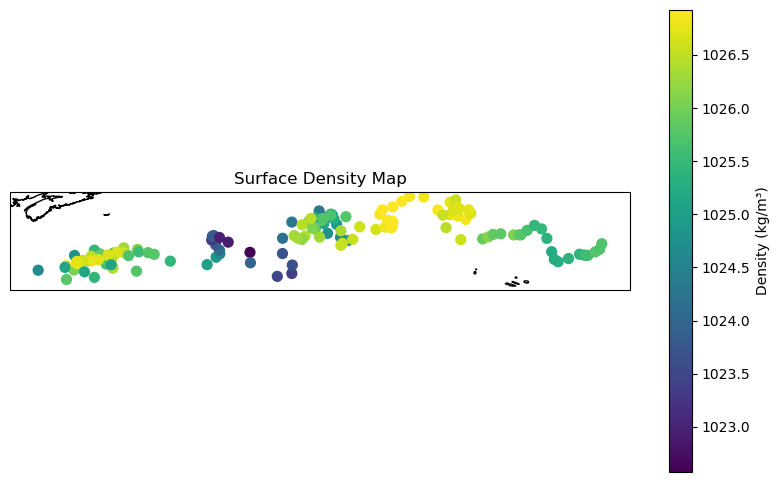

In [18]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# Example: plot average density at surface
avg_rho_surface = rho[:, 0]  # assuming first index is shallowest depth

plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
sc = ax.scatter(lon, lat, c=avg_rho_surface, cmap='viridis', s=50)
ax.coastlines()
plt.colorbar(sc, label='Density (kg/m³)')
plt.title("Surface Density Map")
plt.show()


In [19]:
import pandas as pd

# Convert time to pandas datetime
times = pd.to_datetime(ds['TIME'].values)

# Example: filter data after Jan 1, 2020
filtered = ds.sel(TIME=times > pd.Timestamp("2020-01-01"))


KeyError: "No variable named 'TIME'. Variables on the dataset include ['DATA_TYPE', 'FORMAT_VERSION', 'HANDBOOK_VERSION', 'REFERENCE_DATE_TIME', 'DATE_CREATION', ..., 'PARAMETER', 'SCIENTIFIC_CALIB_EQUATION', 'SCIENTIFIC_CALIB_COEFFICIENT', 'SCIENTIFIC_CALIB_COMMENT', 'SCIENTIFIC_CALIB_DATE']"